# Analyse SHAP values

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import shap
import pickle
import sys
import matplotlib
sys.path.append("../")
PATH = "../../"

from func_preprocess import read_data, subset_wo_missigness, remove_NA, parseVariables, clean_data, impute_scale 
sns.set_theme(style="white", font_scale=1.4, context="paper") #palette=sns.husl_palette(n_colors=8)

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
varDecoding = {
    "gender":"gender",
    "age_erstmanifestation":"age at disease onset",
    "Diagnosedauer":"time to diagnosis ",
    "achrak_rb":"Anti-AChR ab",
    "antimuskak_rb":"Anti-MuSK ab",
    "pyridostigmin_sprb":"medication with pyridostigmine",
    "thymektomie_gr":"thymectomy",
    "immuntherapie_grrb":"therapy with immunosuppressants",
    "exazerbationstherapie_grrb":"excerbation therapy",
    "eskalationstherapiebeitherapierefraktaerermyasthenie_grrb":"escalation therapy",
    "autoimmunerkrankungen_rbzu":"autoimmune diseases (other)",
    "scoreadl_neu":"MG-ADL",
    "mgfaklassifikation_schlimmste_historisch_rb":"MGFA (worst)",
    "aktuelle_MGFA_umkodiert":"MGFA (current)",
    "muskelschmerz":"muscle pain",
    "zn_myasthener_exazerbation":"previous MG exacerbation",
}

In [3]:
### Read dataset and split
PATH_base = "/home/sonja/PROJECTS/myaReg-genderDifferences" ## WUR/katz001 ## 

''' 
Prepare data --> change here for different setups!
'''
target = "gender"
percentBoruta = 100
CV_repeats = 30

''' 
Select features
'''
# varFolder = "CV_v3_mgfaRecoded" #_mgfaRecoded"
# var = f"{target}_bootstrapped_iterativeBoruta_{percentBoruta}perc"
varFolder = "manual_selection"
var = f"allVars_mgfaRecoded"    

varPath = f"{PATH_base}/results/20_featureSelection/{varFolder}/{var}.txt"
sel_variables = pd.read_csv(varPath, header=None)[0].tolist()

''' 
Define paths
'''
resultsPath = f"{PATH_base}/results/30_predictions/{varFolder}/{var}/SHAP"
os.makedirs(resultsPath, exist_ok=True)
figurePath = f"{PATH_base}/figures/{varFolder}/{var}"
os.makedirs(figurePath, exist_ok=True)


''' 
get data
'''
data = read_data(PATH_base, FILENAME="all_data_edited_v3_mgfaRecoded_inverse")  
var_subset_analysis =  False
if var_subset_analysis: 
    data = subset_wo_missigness(data, var_subset_analysis)
data_clean = remove_NA(data, cutoff_perc=35)
##
##
data_clean_parsed = clean_data(data_clean_parsed)
##
df_imputedScaled, df_reverseTransform = impute_scale(data_clean_parsed, ohe_yn=False)

''' 
Get only variables of intereste
'''
df_imputedScaled = df_imputedScaled.loc[:,sel_variables]
df_reverseTransform = df_reverseTransform.loc[:,sel_variables]


'''
Split in X and y
'''
X = data_clean_parsed.drop(target, axis=1)
y = data_clean_parsed[target]



''' Load SHAP'''
with open(f"{resultsPath}/repeatedDCV_{CV_repeats}iter_shap.p", "rb") as f:
    shap_values_per_cv = pickle.load(f)

''' Load predicted probabilities of label 1'''
with open(f"{resultsPath}/repeatedDCV_{CV_repeats}iter_predProb.p", "rb") as f:
    predProb_per_cv = pickle.load(f)


''' 
Average SHAP 

Establish lists to keep average Shap values, their Stds, and their min and max
'''

average_shap_values, stds, ranges = [],[],[]

for i in range(0,len(X)):
    df_per_obs = pd.DataFrame.from_dict(shap_values_per_cv[i]) # Get all SHAP values for sample number i
    # Get relevant statistics for every sample 
    average_shap_values.append(df_per_obs.mean(axis=1).values) 
    stds.append(df_per_obs.std(axis=1).values)
    ranges.append(df_per_obs.max(axis=1).values-df_per_obs.min(axis=1).values)






LOADING DATA


REMOVING MISSINGNESS (cutoff=35%)
Keeping 36/41 variables
Discarded: ['testergebnisdekrement_rb', 'testergebnispyridostigmin_rb', 'lrp4antikoerper_rb', 'histologie_sprb', 'scoreqmg_neu']


REMOVING BIASING / UNWANTED VARIABLES
Discarded: ['zn_myasthener_krise_jn', 'aktueller_mgfa_score', 'okulaer', 'bulbaer', 'generalisiertemuskelschwaeche', 'kortison_sprb', 'azathioprin_sprb', 'methotrexatfolsauure_sprb', 'mycophenolatmofetil_sprb', 'eculizumab_sprb', 'rituximab_sprb', 'plasmapherese_sprb', 'immunadsorption_sprb', 'ivig_sprb', 'age', 'age_bei_diagnose', 'seronegativ', 'scoreqol_neu', 'chronicfatigue_neu', 'seelischesbefinden_neu']
(1814, 16)


CLEANING DATASET


IMPUTING & SCALING




## Summary Plot for SHAP

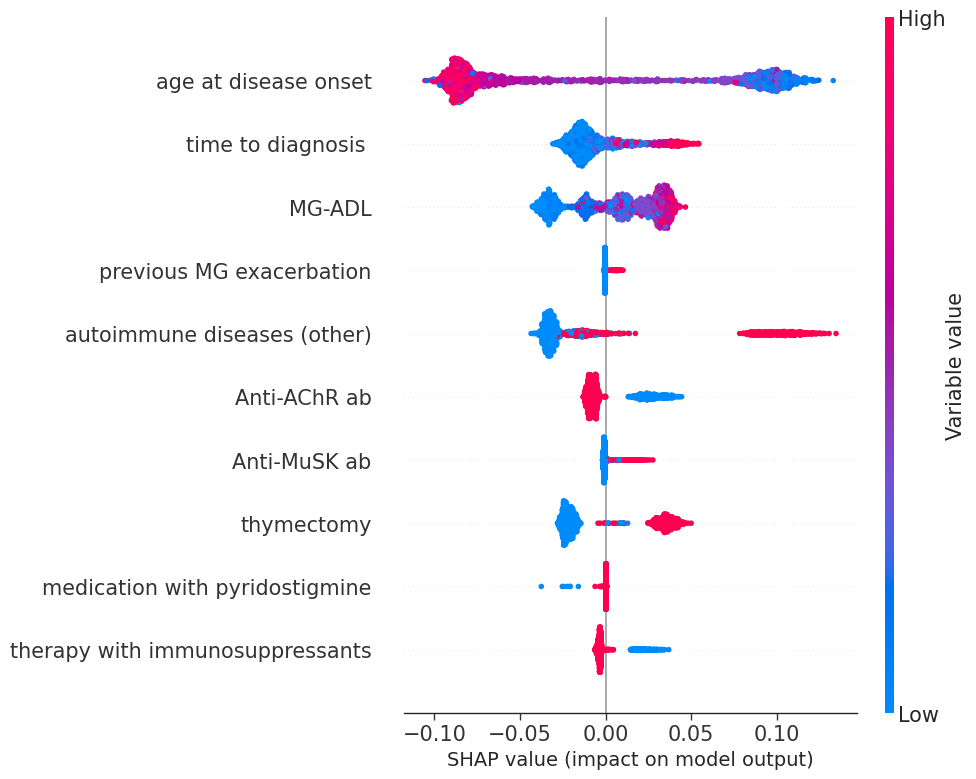

In [6]:
### decode variables for final plotting
df_plotting = df_reverseTransform.rename(columns=varDecoding) 
shap.summary_plot(np.array(average_shap_values), df_plotting, show=False, max_display = 10, sort=False, plot_size=(10.0,8.0))

# Get the current figure and axes objects. from @GarrettCGraham code
fig, ax = plt.gcf(), plt.gca()

# Modifying main plot parameters
ax.tick_params(labelsize=15)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=14)

# Get colorbar
cb_ax = fig.axes[1] 

# Modifying color bar parameters
cb_ax.tick_params(labelsize=15)
cb_ax.set_ylabel("Variable value", fontsize=15)

#plt.show()


##plt.title(f'Average SHAP values after {CV_repeats}x DCV')
plt.tight_layout()
plt.savefig(f"{figurePath}/DCV_SHAP_top10_final.png", dpi=300)

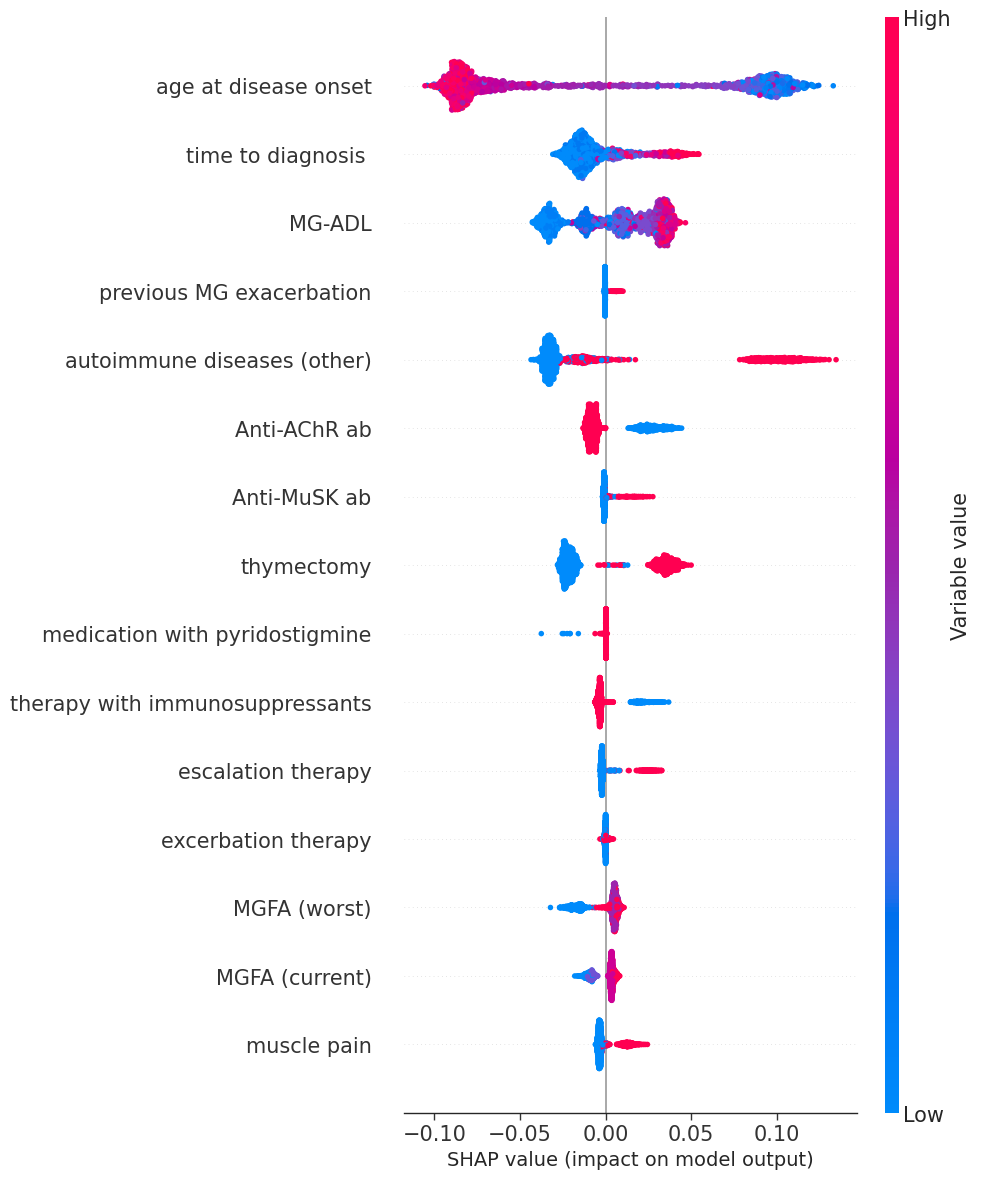

In [5]:
### decode variables for final plotting
df_plotting = df_reverseTransform.rename(columns=varDecoding) 
shap.summary_plot(np.array(average_shap_values), df_plotting, show=False, max_display = 20, sort=False, plot_size=(10.0,12.0))

# Get the current figure and axes objects. from @GarrettCGraham code
fig, ax = plt.gcf(), plt.gca()

# Modifying main plot parameters
ax.tick_params(labelsize=15)
ax.set_xlabel("SHAP value (impact on model output)", fontsize=14)

# Get colorbar
cb_ax = fig.axes[1] 

# Modifying color bar parameters
cb_ax.tick_params(labelsize=15)
cb_ax.set_ylabel("Variable value", fontsize=15)

#plt.show()


##plt.title(f'Average SHAP values after {CV_repeats}x DCV')
plt.tight_layout()
plt.savefig(f"{figurePath}/DCV_SHAP_final.png", dpi=300)